# Evaluate reconstructor AE 

Multi-ocean evaluation & plotting script for the ProfileReconstructor autoencoder.

Loops over the 3 oceans trained` (atlantic,
pacific, indian), reloads each ocean's saved artifacts:
- `best_reconstructor.pth`
- `norm_stats_per_level.npz`
- `reconstructor_metrics.pkl`

Plots are shown and saved  under:
```
EVAL_OUTPUT_BASE_DIR/<ocean>/plots_report_fr/
    01_loss_curve_fr.png
    02_rmse_comparison_fr.png
    03_rmse_by_depth_band_fr.png
    04_variance_explained_fr.png
    05_profile_examples_fr.png
    06_prediction_map_fr.png
    metrics_report_fr.txt
EVAL_OUTPUT_BASE_DIR/ocean_comparison/
    00_rmse_by_ocean_fr.png
    rapport_global_fr.txt
```

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
 
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)
 
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

## 2. Configuration -- edit paths/labels if needed

In [2]:
years_range = "2021_2025"
OCEAN_CONFIGS = {
    "atlantic": {
        "preproc_dir": f"/work/drgarcia/Dataset/DL_datasets/atlantic_ocean/{years_range}/split_time_ascA_dmodeD_masked_grid100",
        "output_dir":  f"/work/drgarcia/Models_and_results/Autoencoder/reconstructor_atlantic_{years_range}",
    },
    "pacific": {
        "preproc_dir": f"/work/drgarcia/Dataset/DL_datasets/pacific_ocean/{years_range}/split_time_ascA_dmodeD_masked_grid100",
        "output_dir":  f"/work/drgarcia/Models_and_results/Autoencoder/reconstructor_pacific_{years_range}",
    },
    "indian": {
        "preproc_dir": f"/work/drgarcia/Dataset/DL_datasets/indian_ocean/{years_range}/split_time_ascA_dmodeD_masked_grid100",
        "output_dir":  f"/work/drgarcia/Models_and_results/Autoencoder/reconstructor_indian_{years_range}",
    },
}
 
EVAL_OUTPUT_BASE_DIR = f"/work/drgarcia/Models_and_results/Autoencoder/reconstructor_alloceans_{years_range}"
COMPARISON_DIR = os.path.join(EVAL_OUTPUT_BASE_DIR, "ocean_comparison")
 
OCEAN_LABELS_FR = {"atlantic": "Atlantique", "pacific": "Pacifique", "indian": "Indien"}
SPLIT_LABELS_FR = {"train": "Entrainement", "val": "Validation", "test": "Test"}
VAR_LABELS_FR = {"TEMP": "Temperature", "PSAL": "Salinite"}
VAR_UNITS_FR = {"TEMP": "degC", "PSAL": "PSU"}
CLASS_LABELS_FR = {"normal": "Normal", "anomaly": "Anomalie"}
 
SEVERITY_ORDER = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5}
BAD_LEVEL_QC_FLAGS = {3, 4}
 
PLATFORM_COL = "PLATFORM_NUMBER"
CYCLE_COL = "CYCLE_NUMBER"
LAT_COL_CANDIDATES = ["LATITUDE", "LAT", "latitude", "lat"]
LON_COL_CANDIDATES = ["LONGITUDE", "LON", "longitude", "lon"]
 
N_EXAMPLES = 4
LATENT_DIM = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Ordre fixe dans lequel les oceans doivent etre traites (atlantique -> pacifique -> indien)
OCEAN_ORDER = ["atlantic", "pacific", "indian"]


## 3. Model (must match the architecture used at training time)

In [3]:
class ProfileReconstructor(nn.Module):
    def __init__(self, n_channels_in=8, n_channels_out=2, seq_len=100, latent_dim=32):
        super().__init__()
        assert seq_len % 4 == 0
        self.seq_len_4 = seq_len // 4
        self.enc1 = nn.Conv1d(n_channels_in, 16, kernel_size=5, padding=2)
        self.bn_e1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn_e2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn_e3 = nn.BatchNorm1d(64)
        self.gpool = nn.AdaptiveAvgPool1d(1)
        self.fc_enc = nn.Linear(64, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 64 * self.seq_len_4)
        self.deconv1 = nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1)
        self.bn_d1 = nn.BatchNorm1d(32)
        self.deconv2 = nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1)
        self.bn_d2 = nn.BatchNorm1d(16)
        self.out_conv = nn.Conv1d(16, n_channels_out, kernel_size=3, padding=1)
 
    def encode(self, x):
        h = torch.relu(self.bn_e1(self.enc1(x)))
        h = self.pool1(h)
        h = torch.relu(self.bn_e2(self.enc2(h)))
        h = self.pool2(h)
        h = torch.relu(self.bn_e3(self.enc3(h)))
        pooled = self.gpool(h).squeeze(-1)
        return self.fc_enc(pooled)
 
    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 64, self.seq_len_4)
        h = torch.relu(self.bn_d1(self.deconv1(h)))
        h = torch.relu(self.bn_d2(self.deconv2(h)))
        return self.out_conv(h)
 
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


## 4. Data load

In [4]:

def load_split_raw(preproc_dir, name):
    X_temp = np.load(os.path.join(preproc_dir, f"{name}_X_temp.npy"))
    X_psal = np.load(os.path.join(preproc_dir, f"{name}_X_psal.npy"))
    mask   = np.load(os.path.join(preproc_dir, f"{name}_mask.npy"))
    meta   = pd.read_parquet(os.path.join(preproc_dir, f"{name}_meta.parquet"))
    labels = meta["is_bad"].values.astype(np.int8)
    return X_temp, X_psal, mask, meta, labels
 
 
def compute_gradient_channels(X, mask, P_grid):
    dP = np.gradient(P_grid).astype(np.float32)
    dP = np.where(dP == 0, 1e-3, dP)
    dX = np.gradient(X, axis=1) / dP[None, :]
    d2X = np.gradient(dX, axis=1) / dP[None, :]
    dX = np.where(mask, dX, 0.0).astype(np.float32)
    d2X = np.where(mask, d2X, 0.0).astype(np.float32)
    return dX, d2X
 
 
def build_profile_tensor(X_temp, X_psal, mask, dT, d2T, dS, d2S, P_norm_row,
                          T_mean_L, T_std_L, S_mean_L, S_std_L,
                          dT_mu, dT_sd, d2T_mu, d2T_sd, dS_mu, dS_sd, d2S_mu, d2S_sd):
    T_norm = np.where(mask, (X_temp - T_mean_L[None, :]) / T_std_L[None, :], 0.0).astype(np.float32)
    S_norm = np.where(mask, (X_psal - S_mean_L[None, :]) / S_std_L[None, :], 0.0).astype(np.float32)
    P_norm = np.broadcast_to(P_norm_row, T_norm.shape).astype(np.float32)
    M_chan = mask.astype(np.float32)
    dT_norm  = np.where(mask, (dT  - dT_mu)  / dT_sd,  0.0).astype(np.float32)
    d2T_norm = np.where(mask, (d2T - d2T_mu) / d2T_sd, 0.0).astype(np.float32)
    dS_norm  = np.where(mask, (dS  - dS_mu)  / dS_sd,  0.0).astype(np.float32)
    d2S_norm = np.where(mask, (d2S - d2S_mu) / d2S_sd, 0.0).astype(np.float32)
    profiles = np.stack([T_norm, S_norm, P_norm, M_chan, dT_norm, d2T_norm, dS_norm, d2S_norm], axis=1)
    target = np.stack([T_norm, S_norm], axis=1)
    return profiles.astype(np.float32), target.astype(np.float32)
 
 
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


## Chargement des donnes par ocean

In [5]:

def load_ocean_data(ocean_key, cfg):
    """Charge metriques + (si possible) modele/donnees test pour un ocean.
    Ne genere AUCUN plot ni tableau : uniquement la preparation des donnees.
    """
    ocean_fr = OCEAN_LABELS_FR[ocean_key]
    preproc_dir = cfg["preproc_dir"]
    output_dir = cfg["output_dir"]
 
    eval_dir = os.path.join(EVAL_OUTPUT_BASE_DIR, ocean_key)
    plots_dir = os.path.join(eval_dir, "plots_report_fr")
    os.makedirs(plots_dir, exist_ok=True)
 
    norm_stats_path = os.path.join(output_dir, "norm_stats_per_level.npz")
    metrics_path = os.path.join(output_dir, "reconstructor_metrics.pkl")
    best_model_path = os.path.join(output_dir, "best_reconstructor.pth")
 
    stats = np.load(norm_stats_path)
    pressure_grid = stats["pressure_grid"]
    T_mean_L, T_std_L = stats["T_mean_L"], stats["T_std_L"]
    S_mean_L, S_std_L = stats["S_mean_L"], stats["S_std_L"]
    grid_max_pres = float(stats["grid_max_pres"][0])
    dT_mu, dT_sd = float(stats["dT_mu"]), float(stats["dT_sd"])
    d2T_mu, d2T_sd = float(stats["d2T_mu"]), float(stats["d2T_sd"])
    dS_mu, dS_sd = float(stats["dS_mu"]), float(stats["dS_sd"])
    d2S_mu, d2S_sd = float(stats["d2S_mu"]), float(stats["d2S_sd"])
    p_norm_row = (pressure_grid / grid_max_pres).astype(np.float32)
    n_vert_levels = len(pressure_grid)
 
    metrics = joblib.load(metrics_path)
 
    data = {
        "ocean_key": ocean_key, "ocean_fr": ocean_fr, "eval_dir": eval_dir,
        "plots_dir": plots_dir, "metrics": metrics, "pressure_grid": pressure_grid,
        "model": None, "profiles_test": None, "target_test": None, "mask_test": None,
        "labels_test": None, "meta_test": None, "platform_ids": None, "cycle_ids": None,
        "T_mean_L": T_mean_L, "T_std_L": T_std_L, "S_mean_L": S_mean_L, "S_std_L": S_std_L,
        "pred_stats": None,
    }
 
    try:
        model = ProfileReconstructor(n_channels_in=8, n_channels_out=2,
                                      seq_len=n_vert_levels, latent_dim=LATENT_DIM).to(DEVICE)
        model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
        model.eval()
 
        X_temp_test, X_psal_test, mask_test, meta_test, labels_test = load_split_raw(preproc_dir, "test")
        dT_test, d2T_test = compute_gradient_channels(X_temp_test, mask_test, pressure_grid)
        dS_test, d2S_test = compute_gradient_channels(X_psal_test, mask_test, pressure_grid)
        profiles_test, target_test = build_profile_tensor(
            X_temp_test, X_psal_test, mask_test, dT_test, d2T_test, dS_test, d2S_test,
            p_norm_row, T_mean_L, T_std_L, S_mean_L, S_std_L,
            dT_mu, dT_sd, d2T_mu, d2T_sd, dS_mu, dS_sd, d2S_mu, d2S_sd)
 
        platform_ids = meta_test[PLATFORM_COL].values if PLATFORM_COL in meta_test.columns else np.array(["N/A"] * len(meta_test))
        cycle_ids = meta_test[CYCLE_COL].values if CYCLE_COL in meta_test.columns else np.array(["N/A"] * len(meta_test))
 
        data.update({
            "model": model, "profiles_test": profiles_test, "target_test": target_test,
            "mask_test": mask_test, "labels_test": labels_test, "meta_test": meta_test,
            "platform_ids": platform_ids, "cycle_ids": cycle_ids,
        })
    except FileNotFoundError as e:
        print(f"  [{ocean_fr}] donnees/modele introuvables, plots bases sur le modele ignores: {e}")
 
    return data


## Plot functions

In [6]:

def plot_loss_curve(metrics, ocean_fr, plots_dir):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(metrics["train_losses"], label="Entrainement")
    ax.plot(metrics["val_normal_losses"], label="Validation (profils normaux)")
    ax.plot(metrics["val_all_losses_diagnostic"], label="Validation (tous, diagnostic)",
            alpha=0.5, linestyle="--")
    ax.set_xlabel("Epoque")
    ax.set_ylabel("Erreur quadratique moyenne (MSE)")
    ax.set_title(f"Courbe d'apprentissage - Ocean {ocean_fr}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "01_loss_curve_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)
 
 
def plot_rmse_comparison(metrics, ocean_fr, plots_dir, split="test"):
    ae = metrics[split]["ae_summary"]
    lm = metrics[split]["level_mean_baseline_summary"]
    poly = metrics[split]["poly_baseline_summary"]
 
    variables = ["TEMP", "PSAL"]
    classes = ["normal", "anomaly"]
    methods = [("Autoencodeur", ae), ("Moyenne par niveau", lm), ("Ajustement polynomial", poly)]
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    x = np.arange(len(classes))
    width = 0.25
 
    for ax, var in zip(axes, variables):
        for i, (method_name, summary) in enumerate(methods):
            vals = [summary[var][cls]["mean"] for cls in classes]
            ax.bar(x + (i - 1) * width, vals, width, label=method_name)
        ax.set_xticks(x)
        ax.set_xticklabels([CLASS_LABELS_FR[c] for c in classes])
        ax.set_ylabel(f"RMSE ({VAR_UNITS_FR[var]})")
        ax.set_title(f"{VAR_LABELS_FR[var]}")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
 
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(f"Reconstruction: autoencodeur vs references - Ocean {ocean_fr} "
                 f"(split {SPLIT_LABELS_FR[split]})")
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "02_rmse_comparison_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)
 
 
def plot_rmse_by_depth_band(metrics, ocean_fr, plots_dir, split="test"):
    band_df = metrics[split]["rmse_by_depth_band"]
    bands = band_df["band"].unique().tolist()
    x = np.arange(len(bands))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, cls in enumerate(["normal", "anomaly"]):
        vals = [band_df[(band_df["band"] == b) & (band_df["class"] == cls)]["mse_mean"].values[0]
                for b in bands]
        ax.bar(x + (i - 0.5) * width, vals, width, label=CLASS_LABELS_FR[cls])
    ax.set_xticks(x)
    ax.set_xticklabels(bands)
    ax.set_xlabel("Tranche de profondeur")
    ax.set_ylabel("Erreur quadratique moyenne (canaux TEMP+PSAL normalises)")
    ax.set_title(f"Erreur de reconstruction par profondeur - Ocean {ocean_fr}")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "03_rmse_by_depth_band_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)
 
 
def plot_variance_explained(metrics, ocean_fr, plots_dir, split="test"):
    df = metrics[split]["variance_explained_by_level"]
    fig, ax = plt.subplots(figsize=(6, 6))
    for var, color in [("TEMP", "tab:blue"), ("PSAL", "tab:orange")]:
        sub = df[df["channel"] == var].sort_values("pressure")
        ax.plot(sub["r2"], sub["pressure"], color=color, label=VAR_LABELS_FR[var])
    ax.invert_yaxis()
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_xlabel("Variance expliquee (R2, profils normaux)")
    ax.set_ylabel("Pression (dbar)")
    ax.set_title(f"Variance expliquee par niveau - Ocean {ocean_fr}")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "04_variance_explained_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)
 
 
def compute_profile_reconstruction(model, profiles_test, target_test, mask_test,
                                    T_mean_L, T_std_L, S_mean_L, S_std_L):
    """Calcule la reconstruction denormalisee + le RMSE par profil.
    Se fait UNE fois par ocean, avant tout plot, pour pouvoir reutiliser
    rmse_t_profile / rmse_s_profile a la fois dans plot_profile_examples
    et dans plot_prediction_map."""
    with torch.no_grad():
        recon, _ = model(torch.from_numpy(profiles_test).to(DEVICE))
        recon = recon.cpu().numpy()
 
    def denorm_temp(v):
        return v * T_std_L + T_mean_L
 
    def denorm_psal(v):
        return v * S_std_L + S_mean_L
 
    temp_true = np.apply_along_axis(denorm_temp, 1, target_test[:, 0, :])
    temp_pred = np.apply_along_axis(denorm_temp, 1, recon[:, 0, :])
    psal_true = np.apply_along_axis(denorm_psal, 1, target_test[:, 1, :])
    psal_pred = np.apply_along_axis(denorm_psal, 1, recon[:, 1, :])
    m = mask_test.astype(bool)
 
    diff2_t = np.where(m, (temp_true - temp_pred) ** 2, np.nan)
    diff2_s = np.where(m, (psal_true - psal_pred) ** 2, np.nan)
    with np.errstate(invalid="ignore"):
        rmse_t_profile = np.sqrt(np.nanmean(diff2_t, axis=1))
        rmse_s_profile = np.sqrt(np.nanmean(diff2_s, axis=1))
 
    return {
        "temp_true": temp_true, "temp_pred": temp_pred,
        "psal_true": psal_true, "psal_pred": psal_pred,
        "m": m, "rmse_t_profile": rmse_t_profile, "rmse_s_profile": rmse_s_profile,
    }
 
 
def plot_profile_examples(indices, title, filename, recon_data, pressure_grid,
                           platform_ids, cycle_ids, plots_dir,
                           bad_temp_mask=None, bad_psal_mask=None, bad_pres_mask=None,
                           is_bad_mask=None, n=N_EXAMPLES):
    """Trace des exemples de profils (observe vs reconstruit), avec le RMSE
    dans le titre et les niveaux QC 3/4 marques en rouge.
 
    indices : tableau d'indices (ex. idx_normal ou idx_anomaly) parmi lesquels
              on tire aleatoirement `n` profils a afficher.
    bad_*_mask : tableaux booleens [n_profils, n_niveaux] optionnels indiquant
                 les niveaux avec QC mauvais (flag 3 ou 4). Si absents, aucun
                 point n'est marque en rouge.
    is_bad_mask : tableau booleen [n_profils] optionnel, flag global du profil
                  (utilise si aucun niveau individuel n'est marque mauvais).
    """
    if len(indices) == 0:
        print(f"  (aucun profil pour '{title}', ignore)")
        return
 
    m = recon_data["m"]
    temp_true_dn, temp_pred_dn = recon_data["temp_true"], recon_data["temp_pred"]
    psal_true_dn, psal_pred_dn = recon_data["psal_true"], recon_data["psal_pred"]
    rmse_t_profile, rmse_s_profile = recon_data["rmse_t_profile"], recon_data["rmse_s_profile"]
 
    rng = np.random.default_rng(0)
    chosen = rng.choice(indices, size=min(n, len(indices)), replace=False)
 
    # sharey=False permet a CHAQUE sous-graphique d'avoir son propre axe Y et grille
    fig, axes = plt.subplots(2, len(chosen), figsize=(3.5 * len(chosen), 8.5), sharey=False)
    if len(chosen) == 1:
        axes = axes.reshape(2, 1)
 
    max_p = float(pressure_grid.max())
 
    for col, i in enumerate(chosen):
        mi = m[i]
        p = pressure_grid[mi]
        plat, cyc = platform_ids[i], cycle_ids[i]
 
        bad_t = bad_temp_mask[i, mi] if bad_temp_mask is not None else np.zeros_like(mi, dtype=bool)
        bad_s = bad_psal_mask[i, mi] if bad_psal_mask is not None else np.zeros_like(mi, dtype=bool)
        bad_p = bad_pres_mask[i, mi] if bad_pres_mask is not None else np.zeros_like(mi, dtype=bool)
 
        anomaly_types = []
        if bad_t.any():
            anomaly_types.append("TEMP")
        if bad_s.any():
            anomaly_types.append("PSAL")
        if bad_p.any():
            anomaly_types.append("PRES")
        if not anomaly_types and is_bad_mask is not None and is_bad_mask[i]:
            anomaly_types.append("QC global")
 
        qc_str = f"\nAnomalie: {', '.join(anomaly_types)}" if anomaly_types else ""
 
        # --- SOUS-GRAPHIQUE TEMPERATURE ---
        ax_t = axes[0, col]
        ax_t.plot(temp_true_dn[i, mi], p, "o-", ms=3, color="tab:blue")
        ax_t.plot(temp_pred_dn[i, mi], p, "o-", ms=3, color="#355E3B")
 
        bad_t_total = bad_t | bad_p
        if bad_t_total.any():
            ax_t.scatter(temp_true_dn[i, mi][bad_t_total], p[bad_t_total],
                         marker="o", color="#FF1744", edgecolors="none", s=35, zorder=10)
 
        ax_t.set_ylim(max_p, 0)  # Surface (0 dbar) en haut
        ax_t.grid(True, linestyle="--", alpha=0.5, color="gray")
        ax_t.set_title(f"TEMP (RMSE={rmse_t_profile[i]:.3f})\n"
                       f"Plateforme: {plat} | Cycle: {cyc}{qc_str}", fontsize=8.5)
        ax_t.set_ylabel("Pression (dbar)")
 
        # --- SOUS-GRAPHIQUE SALINITE ---
        ax_s = axes[1, col]
        ax_s.plot(psal_true_dn[i, mi], p, "o-", ms=3, color="tab:blue")
        ax_s.plot(psal_pred_dn[i, mi], p, "o-", ms=3, color="#355E3B")
 
        bad_s_total = bad_s | bad_p
        if bad_s_total.any():
            ax_s.scatter(psal_true_dn[i, mi][bad_s_total], p[bad_s_total],
                         marker="o", color="#FF1744", edgecolors="none", s=35, zorder=10)
 
        ax_s.set_ylim(max_p, 0)  # Surface (0 dbar) en haut
        ax_s.grid(True, linestyle="--", alpha=0.5, color="gray")
        ax_s.set_title(f"PSAL (RMSE={rmse_s_profile[i]:.3f}){qc_str}", fontsize=8.5)
        ax_s.set_ylabel("Pression (dbar)")
 
    legend_handles = [
        mlines.Line2D([], [], color="tab:blue", marker="o", ms=4, linestyle="-", label="Observe"),
        mlines.Line2D([], [], color="#355E3B", marker="o", ms=4, linestyle="-", label="Reconstruit"),
        mlines.Line2D([], [], color="#FF1744", marker="o", linestyle="None", markersize=5,
                      label="QC 3/4 (niveau mauvais)"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, frameon=True)
 
    fig.suptitle(title, y=1.11, fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, filename), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
 
 
def plot_prediction_map(meta_test, rmse_t_profile, rmse_s_profile, labels_test, idx_normal,
                         ocean_fr, plots_dir):
    lat_col = find_col(meta_test, LAT_COL_CANDIDATES)
    lon_col = find_col(meta_test, LON_COL_CANDIDATES)
    if lat_col is None or lon_col is None:
        print(f"  [{ocean_fr}] pas de colonnes lat/lon -- carte ignoree")
        return None
 
    lats = meta_test[lat_col].values
    lons = meta_test[lon_col].values
 
    t_thresh = np.nanmean(rmse_t_profile[idx_normal]) + 3 * np.nanstd(rmse_t_profile[idx_normal])
    s_thresh = np.nanmean(rmse_s_profile[idx_normal]) + 3 * np.nanstd(rmse_s_profile[idx_normal])
    pred_anomaly = (rmse_t_profile > t_thresh) | (rmse_s_profile > s_thresh)
    true_anomaly = labels_test.astype(bool)
 
    tp = pred_anomaly & true_anomaly
    fp = pred_anomaly & ~true_anomaly
    fn = ~pred_anomaly & true_anomaly
    tn = ~pred_anomaly & ~true_anomaly
 
    n_pred_pos = tp.sum() + fp.sum()
    n_true_pos = tp.sum() + fn.sum()
    precision = tp.sum() / n_pred_pos if n_pred_pos > 0 else float("nan")
    recall = tp.sum() / n_true_pos if n_true_pos > 0 else float("nan")
 
    cat_style = [
        (tn, "tab:green",  "VN (normal correct)",    10, 0.9),
        (fp, "tab:orange", "FP (fausse alerte)",      10, 0.9),
        (fn, "tab:purple", "FN (anomalie manquee)",   10, 0.9),
        (tp, "tab:red",    "VP (anomalie correcte)",  10, 0.9),
    ]
 
    if HAS_CARTOPY:
        fig = plt.figure(figsize=(11, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
        ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
        for mask_cat, color, label, size, alpha in cat_style:
            ax.scatter(lons[mask_cat], lats[mask_cat], s=size, c=color, alpha=alpha,
                       label=f"{label} (n={mask_cat.sum()})", edgecolors="none",
                       transform=ccrs.PlateCarree(), zorder=2)
        ax.set_extent([lons.min() - 2, lons.max() + 2, lats.min() - 2, lats.max() + 2], crs=ccrs.PlateCarree())
    else:
        fig, ax = plt.subplots(figsize=(11, 6))
        for mask_cat, color, label, size, alpha in cat_style:
            ax.scatter(lons[mask_cat], lats[mask_cat], s=size, c=color, alpha=alpha,
                       label=f"{label} (n={mask_cat.sum()})", edgecolors="none")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, linestyle="--", alpha=0.4)
 
    ax.set_title(f"Carte des predictions (split test) - Ocean {ocean_fr}\n"
                 f"anomalie predite = RMSE TEMP ou PSAL au-dessus du seuil (profils normaux)")
    ax.legend(loc="upper right", markerscale=1.3, fontsize=8, framealpha=0.9)
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "06_prediction_map_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)
 
    return {"precision": precision, "recall": recall, "tp": int(tp.sum()), "fp": int(fp.sum()),
            "fn": int(fn.sum()), "tn": int(tn.sum())}
 
 
def plot_ocean_comparison(all_summaries, comparison_dir):
    oceans = list(all_summaries.keys())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    x = np.arange(len(oceans))
    width = 0.35
 
    for ax, var in zip(axes, ["TEMP", "PSAL"]):
        normal_vals = [all_summaries[o][f"{var.lower()}_rmse_normal"] for o in oceans]
        anomaly_vals = [all_summaries[o][f"{var.lower()}_rmse_anomaly"] for o in oceans]
        ax.bar(x - width / 2, normal_vals, width, label="Normal")
        ax.bar(x + width / 2, anomaly_vals, width, label="Anomalie")
        ax.set_xticks(x)
        ax.set_xticklabels([OCEAN_LABELS_FR[o] for o in oceans])
        ax.set_ylabel(f"RMSE ({VAR_UNITS_FR[var]})")
        ax.set_title(VAR_LABELS_FR[var])
        ax.grid(axis="y", linestyle="--", alpha=0.4)
 
    axes[0].legend()
    fig.suptitle("Comparaison entre oceans - RMSE de l'autoencodeur (Test)")
    fig.tight_layout()
    fig.savefig(os.path.join(comparison_dir, "00_rmse_by_ocean_fr.png"), dpi=150)
    plt.show()
    plt.close(fig)


## Table functions

In [7]:
def build_rmse_comparison_table(metrics, split="test"):
    ae = metrics[split]["ae_summary"]
    lm = metrics[split]["level_mean_baseline_summary"]
    poly = metrics[split]["poly_baseline_summary"]
    rows = []
    for var in ["TEMP", "PSAL"]:
        for cls in ["normal", "anomaly"]:
            rows.append({
                "Variable": VAR_LABELS_FR[var],
                "Classe": CLASS_LABELS_FR[cls],
                "Unite": VAR_UNITS_FR[var],
                "Autoencodeur": round(ae[var][cls]["mean"], 4),
                "Moyenne par niveau": round(lm[var][cls]["mean"], 4),
                "Ajustement polynomial": round(poly[var][cls]["mean"], 4),
            })
    return pd.DataFrame(rows)
 
 
def build_depth_band_table(metrics, split="test"):
    band_df = metrics[split]["rmse_by_depth_band"].copy()
    pivot = band_df.pivot(index="band", columns="class", values="mse_mean").reset_index()
    pivot = pivot.rename(columns={"band": "Tranche de profondeur",
                                   "normal": "MSE Normal", "anomaly": "MSE Anomalie"})
    return pivot.round(5)
 
 
def build_variance_summary_table(metrics, split="test"):
    df = metrics[split]["variance_explained_by_level"]
    bands = metrics["depth_bands"]
    rows = []
    for var in ["TEMP", "PSAL"]:
        sub = df[df["channel"] == var]
        for name, lo, hi in bands:
            band_sub = sub[(sub["pressure"] >= lo) & (sub["pressure"] < hi)]
            rows.append({"Variable": VAR_LABELS_FR[var], "Tranche": name,
                         "R2 moyen": round(float(band_sub["r2"].mean()), 4)})
    return pd.DataFrame(rows)
 
 
def build_confusion_table(pred_stats):
    if pred_stats is None:
        return None
    rows = [{
        "VP (anomalie correcte)": pred_stats["tp"],
        "FP (fausse alerte)": pred_stats["fp"],
        "FN (anomalie manquee)": pred_stats["fn"],
        "VN (normal correct)": pred_stats["tn"],
        "Precision": round(pred_stats["precision"], 3),
        "Rappel": round(pred_stats["recall"], 3),
    }]
    return pd.DataFrame(rows)
 
 
def build_metrics_report_text(metrics, ocean_fr, pred_stats):
    lines = []
    lines.append("=" * 70)
    lines.append(f"RAPPORT DE METRIQUES - OCEAN {ocean_fr.upper()}")
    lines.append("=" * 70)
    for split in ["train", "val", "test"]:
        lines.append(f"\n[ SPLIT: {SPLIT_LABELS_FR[split].upper()} ]")
        overall_t = np.nanmean(metrics[split]["ae_rmse_temp"])
        overall_s = np.nanmean(metrics[split]["ae_rmse_psal"])
        lines.append(f"- RMSE TEMPERATURE global (tous profils) : {overall_t:.4f} degC")
        lines.append(f"- RMSE SALINITE global (tous profils)    : {overall_s:.4f} PSU")
        lines.append("-" * 70)
        table = build_rmse_comparison_table(metrics, split=split)
        lines.append(table.to_string(index=False))
    lines.append(f"\n- Meilleure MSE de validation (profils normaux) : {metrics['best_val_normal_loss']:.5f}")
    if pred_stats is not None:
        lines.append("\n" + "-" * 70)
        lines.append("Detection d'anomalie par seuil de RMSE (moyenne + 3 ecarts-types, test)")
        lines.append("-" * 70)
        lines.append(f"  VP={pred_stats['tp']}  FP={pred_stats['fp']}  FN={pred_stats['fn']}  VN={pred_stats['tn']}")
        lines.append(f"  Precision={pred_stats['precision']:.3f}  Rappel={pred_stats['recall']:.3f}")
    lines.append("")
    return "\n".join(lines)
 
 
def build_ocean_comparison_table(all_summaries):
    rows = []
    for ocean_key, summary in all_summaries.items():
        rows.append({
            "Ocean": OCEAN_LABELS_FR[ocean_key],
            "RMSE TEMP Normal (degC)": round(summary["temp_rmse_normal"], 4),
            "RMSE TEMP Anomalie (degC)": round(summary["temp_rmse_anomaly"], 4),
            "RMSE PSAL Normal (PSU)": round(summary["psal_rmse_normal"], 4),
            "RMSE PSAL Anomalie (PSU)": round(summary["psal_rmse_anomaly"], 4),
        })
    return pd.DataFrame(rows)
 


## 1- Load data for 3 oceans

In [8]:
os.makedirs(EVAL_OUTPUT_BASE_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)
 
all_data = {}
for ocean_key in OCEAN_ORDER:
    cfg = OCEAN_CONFIGS[ocean_key]
    print(f"\n=== Chargement des donnees: {OCEAN_LABELS_FR[ocean_key]} ===")
    try:
        all_data[ocean_key] = load_ocean_data(ocean_key, cfg)
    except Exception as e:
        print(f"!! Echec du chargement pour l'ocean {ocean_key}: {e}")
 
available_oceans = [k for k in OCEAN_ORDER if k in all_data]


=== Chargement des donnees: Atlantique ===

=== Chargement des donnees: Pacifique ===

=== Chargement des donnees: Indien ===


## 2- Plots


COURBE D'APPRENTISSAGE

--- Atlantique ---


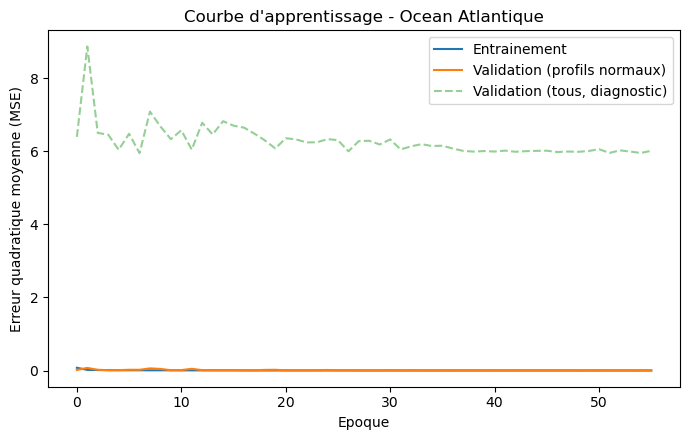


--- Pacifique ---


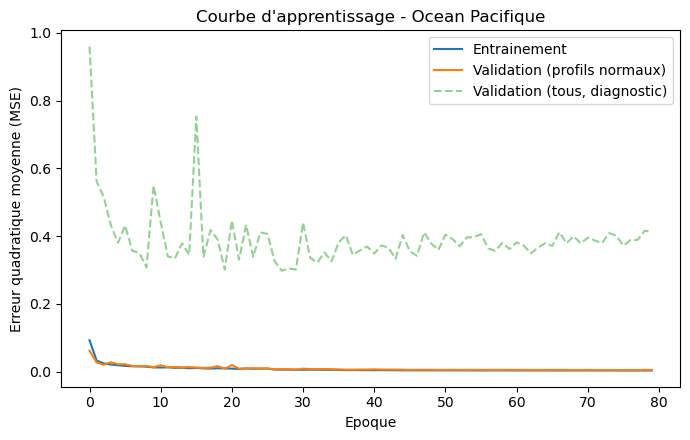


--- Indien ---


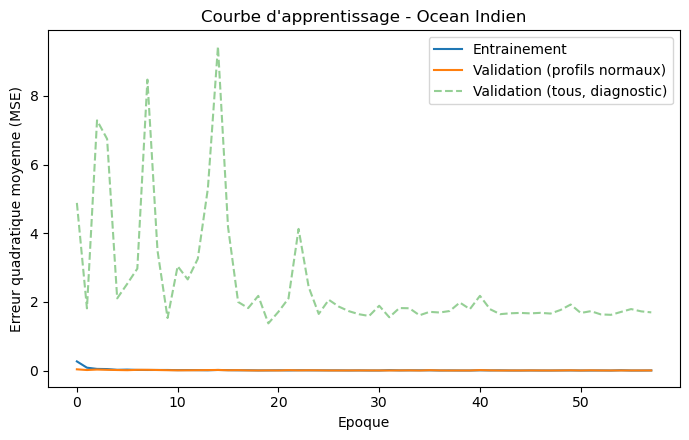


RECONSTRUCTION: AUTOENCODEUR VS REFERENCES

--- Atlantique ---


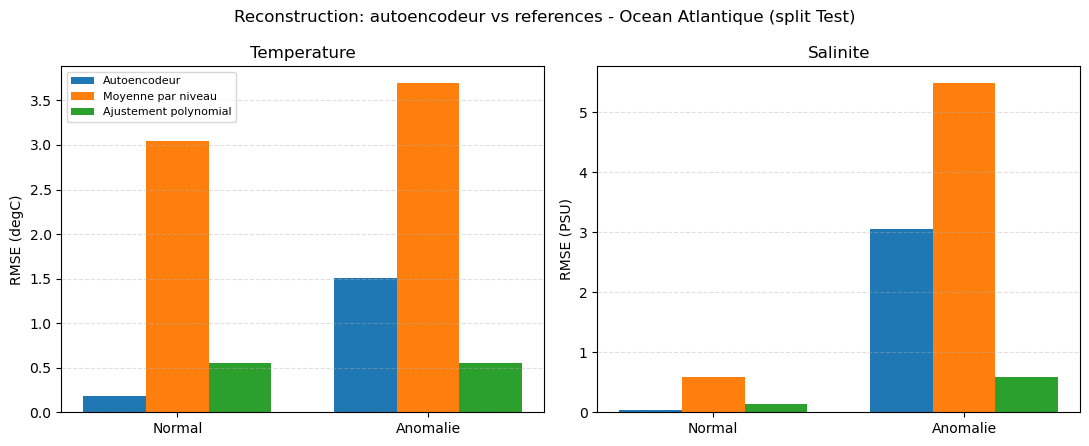


--- Pacifique ---


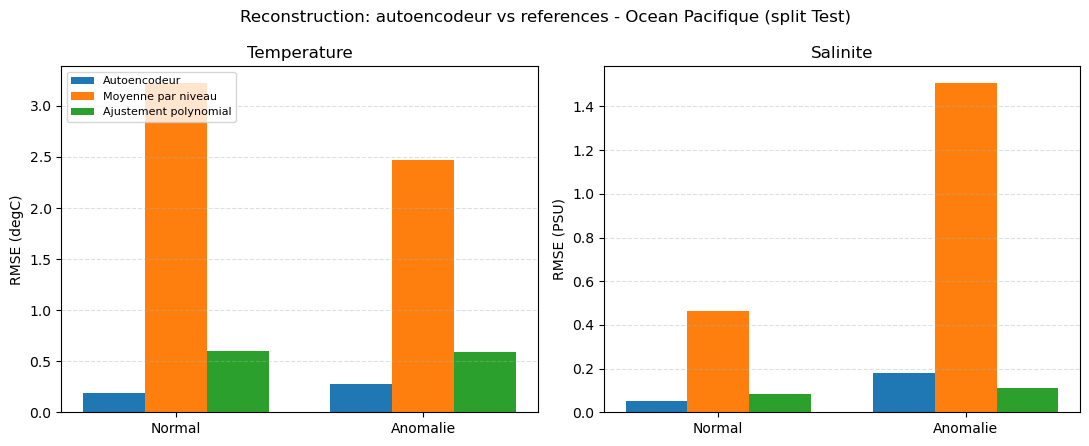


--- Indien ---


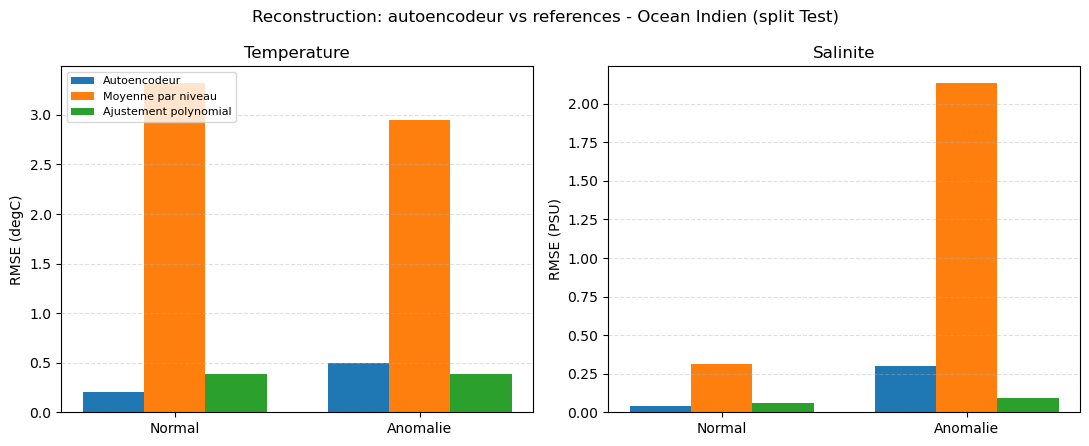


ERREUR DE RECONSTRUCTION PAR PROFONDEUR

--- Atlantique ---


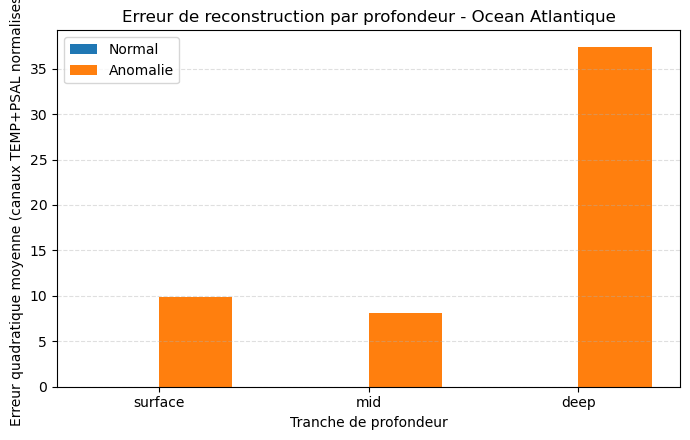


--- Pacifique ---


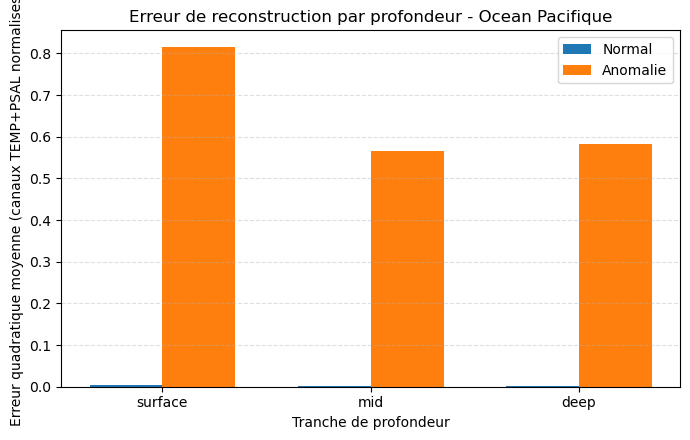


--- Indien ---


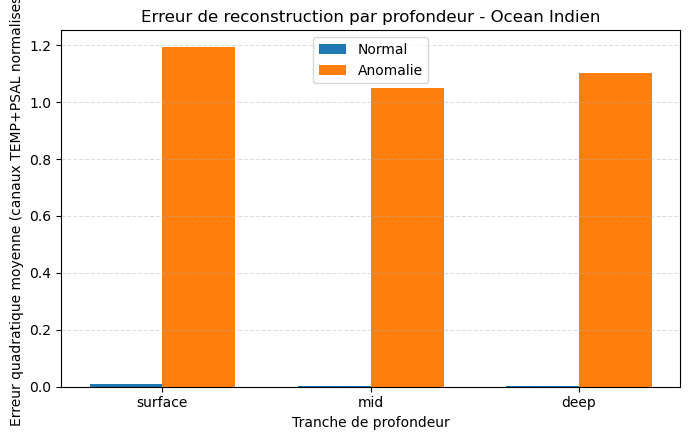


VARIANCE EXPLIQUEE PAR NIVEAU

--- Atlantique ---


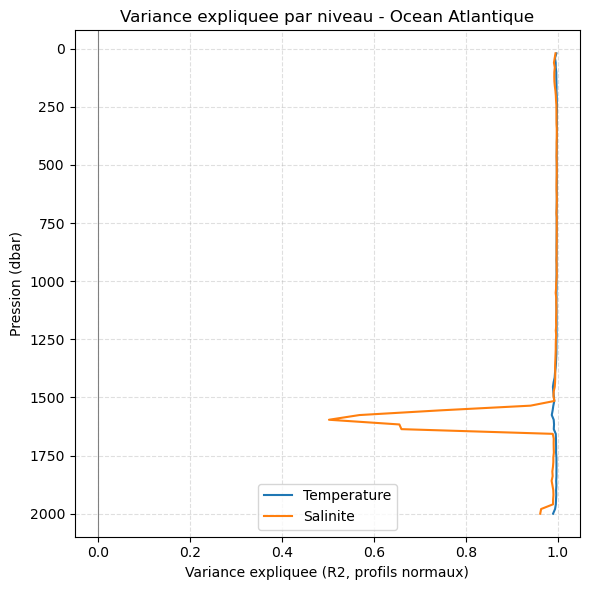


--- Pacifique ---


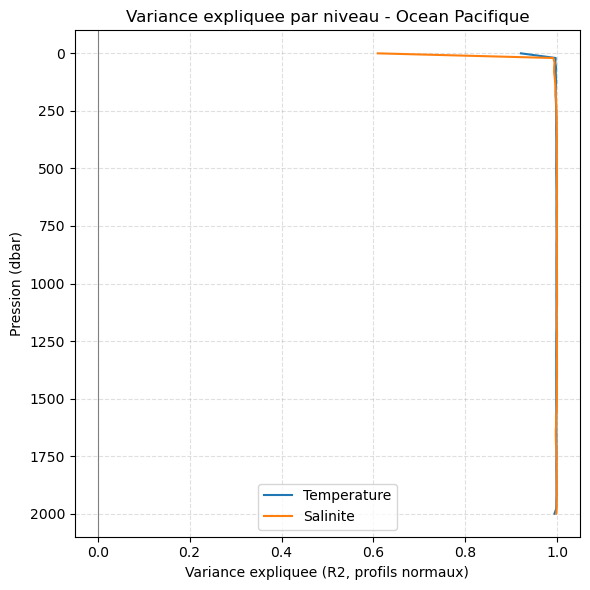


--- Indien ---


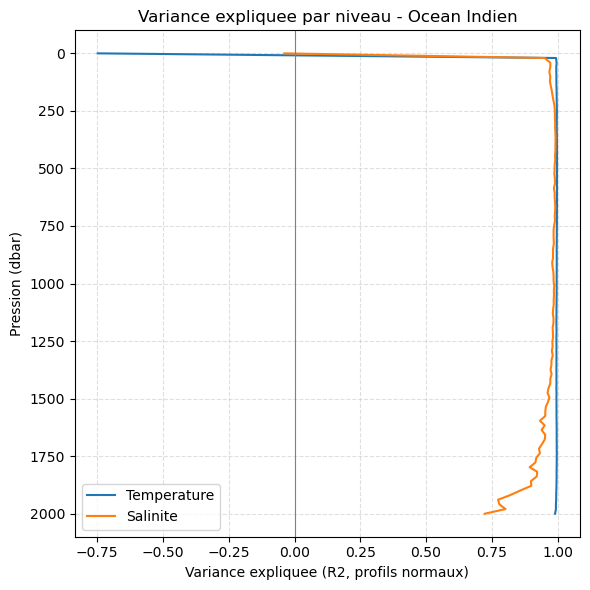


EXEMPLES DE PROFILS: OBSERVE VS RECONSTRUIT

--- Atlantique ---


TypeError: plot_profile_examples() takes from 8 to 13 positional arguments but 14 were given

In [9]:

# --- 1) Courbe d'apprentissage ---
print("\n" + "=" * 70)
print("COURBE D'APPRENTISSAGE")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n--- {d['ocean_fr']} ---")
    plot_loss_curve(d["metrics"], d["ocean_fr"], d["plots_dir"])
 
# --- 2) Comparaison RMSE autoencodeur vs baselines ---
print("\n" + "=" * 70)
print("RECONSTRUCTION: AUTOENCODEUR VS REFERENCES")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n--- {d['ocean_fr']} ---")
    plot_rmse_comparison(d["metrics"], d["ocean_fr"], d["plots_dir"], split="test")
 
# --- 3) RMSE par tranche de profondeur ---
print("\n" + "=" * 70)
print("ERREUR DE RECONSTRUCTION PAR PROFONDEUR")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n--- {d['ocean_fr']} ---")
    plot_rmse_by_depth_band(d["metrics"], d["ocean_fr"], d["plots_dir"], split="test")
 
# --- 4) Variance expliquee par niveau ---
print("\n" + "=" * 70)
print("VARIANCE EXPLIQUEE PAR NIVEAU")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n--- {d['ocean_fr']} ---")
    plot_variance_explained(d["metrics"], d["ocean_fr"], d["plots_dir"], split="test")
 
# --- 5) Exemples de profils observe vs reconstruit ---
print("\n" + "=" * 70)
print("EXEMPLES DE PROFILS: OBSERVE VS RECONSTRUIT")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    if d["model"] is None:
        print(f"\n--- {d['ocean_fr']} : modele/donnees indisponibles, ignore ---")
        continue
    print(f"\n--- {d['ocean_fr']} ---")
    temp_true, temp_pred, psal_true, psal_pred, m = plot_profile_examples(
        d["model"], d["profiles_test"], d["target_test"], d["mask_test"], d["labels_test"],
        d["T_mean_L"], d["T_std_L"], d["S_mean_L"], d["S_std_L"], d["pressure_grid"],
        d["platform_ids"], d["cycle_ids"], d["ocean_fr"], d["plots_dir"])
    # on garde ces resultats pour la carte de predictions (etape suivante)
    d["temp_true"], d["temp_pred"] = temp_true, temp_pred
    d["psal_true"], d["psal_pred"], d["m"] = psal_true, psal_pred, m
 
# --- 6) Carte des predictions ---
print("\n" + "=" * 70)
print("CARTE DES PREDICTIONS (DETECTION D'ANOMALIE)")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    if d["model"] is None or "m" not in d:
        print(f"\n--- {d['ocean_fr']} : modele/donnees indisponibles, ignore ---")
        continue
    print(f"\n--- {d['ocean_fr']} ---")
    diff2_t = np.where(d["m"], (d["temp_true"] - d["temp_pred"]) ** 2, np.nan)
    diff2_s = np.where(d["m"], (d["psal_true"] - d["psal_pred"]) ** 2, np.nan)
    with np.errstate(invalid="ignore"):
        rmse_t_profile = np.sqrt(np.nanmean(diff2_t, axis=1))
        rmse_s_profile = np.sqrt(np.nanmean(diff2_s, axis=1))
    idx_normal = np.where(d["labels_test"] == 0)[0]
    d["pred_stats"] = plot_prediction_map(
        d["meta_test"], rmse_t_profile, rmse_s_profile, d["labels_test"],
        idx_normal, d["ocean_fr"], d["plots_dir"])


## 3 - Print tables

In [10]:

# --- Tableau RMSE reconstruction ---
print("\n" + "=" * 70)
print("TABLEAU: RMSE RECONSTRUCTION (SPLIT TEST)")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n### {d['ocean_fr']} -- RMSE reconstruction (split test) ###")
    display(build_rmse_comparison_table(d["metrics"], split="test"))
 
# --- Tableau RMSE par tranche de profondeur ---
print("\n" + "=" * 70)
print("TABLEAU: RMSE PAR TRANCHE DE PROFONDEUR (SPLIT TEST)")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n### {d['ocean_fr']} -- RMSE par tranche de profondeur (split test) ###")
    display(build_depth_band_table(d["metrics"], split="test"))
 
# --- Tableau variance expliquee ---
print("\n" + "=" * 70)
print("TABLEAU: VARIANCE EXPLIQUEE (R2 MOYEN PAR TRANCHE)")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    print(f"\n### {d['ocean_fr']} -- Variance expliquee (R2 moyen par tranche) ###")
    display(build_variance_summary_table(d["metrics"], split="test"))
 
# --- Tableau de confusion / detection d'anomalie ---
print("\n" + "=" * 70)
print("TABLEAU: DETECTION D'ANOMALIE (SEUIL RMSE, SPLIT TEST)")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    confusion_table = build_confusion_table(d.get("pred_stats"))
    if confusion_table is not None:
        print(f"\n### {d['ocean_fr']} -- Detection d'anomalie (seuil RMSE, split test) ###")
        display(confusion_table)
    else:
        print(f"\n### {d['ocean_fr']} : pas de statistiques de prediction disponibles ###")
 
# --- Rapports texte individuels (ecrits sur disque, un par ocean) ---
print("\n" + "=" * 70)
print("ECRITURE DES RAPPORTS TEXTE INDIVIDUELS")
print("=" * 70)
for ocean_key in available_oceans:
    d = all_data[ocean_key]
    report_text = build_metrics_report_text(d["metrics"], d["ocean_fr"], d.get("pred_stats"))
    report_path = os.path.join(d["eval_dir"], "metrics_report_fr.txt")
    with open(report_path, "w") as f:
        f.write(report_text)
    print(f"[{d['ocean_fr']}] rapport texte ecrit -> {report_path}")



TABLEAU: RMSE RECONSTRUCTION (SPLIT TEST)

### Atlantique -- RMSE reconstruction (split test) ###


,Variable,Classe,Unite,Autoencodeur,Moyenne par niveau,Ajustement polynomial
0,Temperature,Normal,degC,0.1846,3.0483,0.5498
1,Temperature,Anomalie,degC,1.5078,3.6973,0.5539
2,Salinite,Normal,PSU,0.0429,0.5848,0.1316
3,Salinite,Anomalie,PSU,3.0536,5.4887,0.5884



### Pacifique -- RMSE reconstruction (split test) ###


,Variable,Classe,Unite,Autoencodeur,Moyenne par niveau,Ajustement polynomial
0,Temperature,Normal,degC,0.1840,3.2258,0.6036
1,Temperature,Anomalie,degC,0.2723,2.4701,0.5855
2,Salinite,Normal,PSU,0.0523,0.4646,0.0831
3,Salinite,Anomalie,PSU,0.1800,1.5082,0.1122



### Indien -- RMSE reconstruction (split test) ###


...


### Pacifique -- Variance expliquee (R2 moyen par tranche) ###


,Variable,Tranche,R2 moyen
0,Temperature,surface,0.9892
1,Temperature,mid,0.9979
2,Temperature,deep,0.9979
3,Salinite,surface,0.9559
4,Salinite,mid,0.9990
5,Salinite,deep,0.9987



### Indien -- Variance expliquee (R2 moyen par tranche) ###


,Variable,Tranche,R2 moyen
0,Temperature,surface,0.8214
1,Temperature,mid,0.9974
2,Temperature,deep,0.9960
3,Salinite,surface,0.8703
4,Salinite,mid,0.9880
5,Salinite,deep,0.9394



TABLEAU: DETECTION D'ANOMALIE (SEUIL RMSE, SPLIT TEST)

### Atlantique : pas de statistiques de prediction disponibles ###

### Pacifique : pas de statistiques de prediction disponibles ###

### Indien : pas de statistiques de prediction disponibles ###

ECRITURE DES RAPPORTS TEXTE INDIVIDUELS
[Atlantique] rapport texte ecrit -> /work/drgarcia/Models_and_results/Autoencoder/reconstructor_alloceans_2021_2025/atlantic/metrics_report_fr.txt
[Pacifique] rapport texte ecrit -> /work/drgarcia/Models_and_results/Autoencoder/reconstructor_alloceans_2021_2025/pacific/metrics_report_fr.txt
[Indien] rapport texte ecrit -> /work/drgarcia/Models_and_results/Autoencoder/reconstructor_alloceans_2021_2025/indian/metrics_report_fr.txt


## 4. comparasion


COMPARAISON ENTRE OCEANS


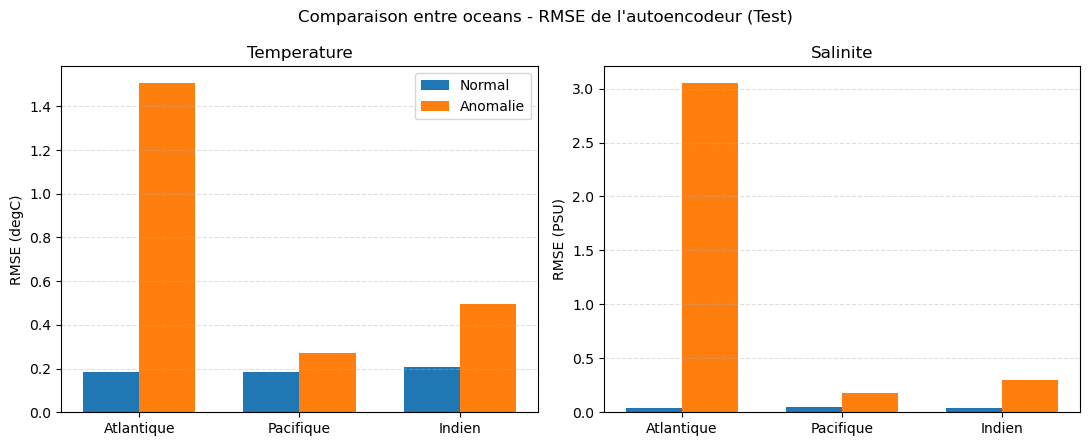


### Comparaison entre oceans (split test) ###


,Ocean,RMSE TEMP Normal (degC),RMSE TEMP Anomalie (degC),RMSE PSAL Normal (PSU),RMSE PSAL Anomalie (PSU)
0,Atlantique,0.1846,1.5078,0.0429,3.0536
1,Pacifique,0.1840,0.2723,0.0523,0.1800
2,Indien,0.2055,0.4976,0.0439,0.3001



(rapport global ecrit -> /work/drgarcia/Models_and_results/Autoencoder/reconstructor_alloceans_2021_2025/ocean_comparison/rapport_global_fr.txt)


In [11]:

if all_data:
    all_summaries = {}
    for ocean_key in available_oceans:
        metrics = all_data[ocean_key]["metrics"]
        summary = {}
        for var in ["TEMP", "PSAL"]:
            summary[f"{var.lower()}_rmse_normal"] = metrics["test"]["ae_summary"][var]["normal"]["mean"]
            summary[f"{var.lower()}_rmse_anomaly"] = metrics["test"]["ae_summary"][var]["anomaly"]["mean"]
        all_summaries[ocean_key] = summary
 
    print("\n" + "=" * 70)
    print("COMPARAISON ENTRE OCEANS")
    print("=" * 70)
    plot_ocean_comparison(all_summaries, COMPARISON_DIR)
 
    print("\n### Comparaison entre oceans (split test) ###")
    comparison_table = build_ocean_comparison_table(all_summaries)
    display(comparison_table)
 
    global_report_path = os.path.join(COMPARISON_DIR, "rapport_global_fr.txt")
    with open(global_report_path, "w") as f:
        f.write("RAPPORT GLOBAL - EVALUATION DES 3 OCEANS\n" + "=" * 70 + "\n\n")
        f.write(comparison_table.to_string(index=False))
    print(f"\n(rapport global ecrit -> {global_report_path})")
